## Tumour identification pipeline

This implements the workflow:

1. Open a `.tif` (single image) or `.lif` (loop over contained images).
2. Extract pixel size from metadata, falling back to a user-supplied value.
3. Take a 2D slice from the requested channel (max-project the Z axis if a stack).
4. If `type="bf"`, invert the image so tumours appear bright on a dark background.
5. Rescale intensities to 0-255 (`uint8`).
6. Threshold to find a single bright region.
7. If the region has low eccentricity, split it with a watershed segmentation.
8. From the split regions, keep the one with the highest mean intensity in the
   rescaled image (this is the tumour).

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterator, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import tifffile
from liffile import LifFile
import csv
import traceback
from skimage import util
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import disk, opening, erosion
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.segmentation import clear_border
from skimage.morphology import ball, dilation, remove_small_holes
import warnings
warnings.filterwarnings("ignore")



In [2]:
def rescale_intensity(img: np.ndarray, target_min: float = 0, target_max: float = 255, target_dtype=np.uint8) -> np.ndarray:
    """Linearly rescale img intensity to [target_min, target_max] and cast."""
    img_min, img_max = float(img.min()), float(img.max())
    if img_max == img_min:
        return np.full_like(img, target_min, dtype=target_dtype)
    scale = (target_max - target_min) / (img_max - img_min)
    offset = target_max - scale * img_max
    return (scale * img + offset).astype(target_dtype)


In [3]:
def get_tiff_pixel_size_um(tif: tifffile.TiffFile) -> Optional[Tuple[float, float]]:
    """Return (y_um_per_px, x_um_per_px) from TIFF metadata, if available."""
    tags = tif.pages[0].tags
    imagej_metadata = getattr(tif, "imagej_metadata", None) or {}
    unit_hint = (imagej_metadata.get("unit") or "").lower()
    if "XResolution" not in tags or "YResolution" not in tags:
        return None
    if not unit_hint and "ResolutionUnit" in tags:
        unit_hint = {2: "inch", 3: "cm"}.get(int(tags["ResolutionUnit"].value), "")
    def resolution_to_um(res, unit):
        num, den = res
        if num == 0:
            return None
        um_per_px = den / num
        if unit == "cm": um_per_px *= 1e4
        elif unit == "mm": um_per_px *= 1e3
        elif unit in ("inch", "in"): um_per_px *= 25_400.0
        return um_per_px
    x_um = resolution_to_um(tags["XResolution"].value, unit_hint)
    y_um = resolution_to_um(tags["YResolution"].value, unit_hint)
    if x_um and y_um:
        return float(y_um), float(x_um)
    return None


def get_lif_pixel_size_um(image) -> Optional[Tuple[float, float]]:
    """Return (y_um_per_px, x_um_per_px) for a liffile image (metadata in metres, converted to µm)."""
    coords = image.asxarray().coords
    if "X" not in coords or coords["X"].size < 2 or "Y" not in coords or coords["Y"].size < 2:
        return None
    x_um = abs(float(coords["X"][1] - coords["X"][0])) * 1e6
    y_um = abs(float(coords["Y"][1] - coords["Y"][0])) * 1e6
    if x_um <= 0 or y_um <= 0:
        return None
    return y_um, x_um


def extract_2d_slice(arr: np.ndarray, axes: str, channel_no: int) -> np.ndarray:
    """Select a 2D YX slice from an arbitrarily-axed array, picking channel_no along C and max-projecting remaining axes."""
    axes = axes.upper()
    arr = np.asarray(arr)
    if len(axes) != arr.ndim:
        if arr.ndim == 2:
            return arr
        if arr.ndim == 3:
            return arr[min(channel_no, arr.shape[0] - 1)]
        sliced = arr[min(channel_no, arr.shape[0] - 1)]
        while sliced.ndim > 2:
            sliced = sliced.max(axis=0)
        return sliced
    if "C" in axes:
        channel_axis_idx = axes.index("C")
        arr = np.take(arr, min(channel_no, arr.shape[channel_axis_idx] - 1), axis=channel_axis_idx)
        axes = axes.replace("C", "")
    while arr.ndim > 2:
        arr = arr.max(axis=0)
    return arr


In [4]:
def iter_images(file_path: Path, bf_channel: int = 0, fluorescent_channel: Optional[int] = None) -> Iterator[Tuple[str, Optional[np.ndarray], Optional[np.ndarray], Tuple[float, float], Optional[str]]]:
    """Yield (name, bf_image_2d, fl_image_2d_or_None, (y_um, x_um), skip_reason) for each image.

    Handles .tif/.tiff (one image) and .lif (loops over contained images).
    If an image has Z or T dimensions with size > 1, both image arrays are None and skip_reason is set.
    If pixel-size metadata is absent, (y_um, x_um) is (nan, nan) and skip_reason is None.
    """
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    if suffix in (".tif", ".tiff"):
        with tifffile.TiffFile(file_path) as tif:
            arr = tif.asarray()
            axes = (tif.series[0].axes or "").upper() or ("YX" if arr.ndim == 2 else "")
            has_zt = any(ax in ("Z", "T") and arr.shape[i] > 1 for i, ax in enumerate(axes) if i < arr.ndim)
            if has_zt:
                yield file_path.stem, None, None, (float("nan"), float("nan")), "skipped: image has Z/T dimensions"
                return
            pixel_size_um = get_tiff_pixel_size_um(tif) or (float("nan"), float("nan"))
            bf_img2d = extract_2d_slice(arr, axes, bf_channel)
            fl_img2d = extract_2d_slice(arr, axes, fluorescent_channel) if fluorescent_channel is not None else None
            yield file_path.stem, bf_img2d, fl_img2d, pixel_size_um, None
        return

    if suffix == ".lif":
        with LifFile(str(file_path)) as lif:
            for image in lif.images:
                has_zt = any(k.upper() in ("Z", "T") and v > 1 for k, v in image.sizes.items())
                if has_zt:
                    yield f"{file_path.stem}__{image.name}", None, None, (float("nan"), float("nan")), "skipped: image has Z/T dimensions"
                    continue
                axes = "".join(image.sizes.keys()).upper()
                arr = np.asarray(image.asarray())
                pixel_size_um = get_lif_pixel_size_um(image) or (float("nan"), float("nan"))
                bf_img2d = extract_2d_slice(arr, axes, bf_channel)
                fl_img2d = extract_2d_slice(arr, axes, fluorescent_channel) if fluorescent_channel is not None else None
                yield f"{file_path.stem}__{image.name}", bf_img2d, fl_img2d, pixel_size_um, None
        return

    raise ValueError(f"Unsupported file type: {suffix}")


In [5]:
def identify_tumour(image_2d: np.ndarray, pixel_size_um: Tuple[float, float], image_type: str = "bf", max_eccentricity: float = 0.6, min_solidity: float = 0.9, min_object_area_um2: float = 5_000.0, erosion_radius_um: float = 60.0) -> dict:
    """Identify the tumour in a 2D image.

    Parameters
    ----------
    image_2d : 2D YX image (any dtype).
    pixel_size_um : (y_um_per_px, x_um_per_px). May be (nan, nan) if metadata was unavailable;
        area_um2 in the result will be NaN and only area_px2 is meaningful.
    image_type : "bf" (brightfield, tumour is dark and image is inverted) or "fluorescent".
    max_eccentricity : eccentricity above which a watershed split is attempted (0=circle, 1=line).
    min_solidity : solidity below which erosion is attempted to separate merged blobs.
    min_object_area_um2 : minimum candidate area for watershed filtering. Ignored when pixel size is NaN.
    erosion_radius_um : radius in µm used to erode the candidate mask before watershed.
    """
    if image_2d.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {image_2d.shape}")
    pixel_size_y, pixel_size_x = float(pixel_size_um[0]), float(pixel_size_um[1])
    area_per_pixel = pixel_size_y * pixel_size_x

    rescaled = rescale_intensity(util.invert(image_2d) if image_type.lower() == "bf" else image_2d, 0, 255, np.uint8)
    smoothed = gaussian(rescaled, sigma=2, preserve_range=True)
    binary = opening(smoothed > threshold_otsu(smoothed), disk(3))

    labelled = label(binary)
    if labelled.max() == 0:
        return {"rescaled": rescaled, "mask": np.zeros_like(binary, dtype=bool), "area_px2": 0.0, "area_um2": 0.0, "eccentricity": 0.0, "split": False}

    regions = regionprops(labelled, intensity_image=rescaled)
    regions.sort(key=lambda r: r.area, reverse=True)
    initial_candidate = regions[0]
    initial_candidate_mask = labelled == initial_candidate.label
    eccentricity = float(initial_candidate.eccentricity)
    solidity = float(initial_candidate.solidity)
    print(f"  eccentricity={eccentricity:.3f}  solidity={solidity:.3f}")

    best_mask = initial_candidate_mask
    eroded = False
    split = False
    eroded_candidate_mask = None
    coords = np.empty((0, 2), dtype=int)

    # ── Step 1: low solidity → erode to separate merged blobs ─────────────────
    if solidity < min_solidity:
        print(f"  Low solidity ({solidity:.2f}) — attempting erosion")
        eroded_image = erosion(initial_candidate_mask, disk(int(erosion_radius_um / pixel_size_y)))
        eroded_labels = label(eroded_image)
        print(f"  {eroded_labels.max()} component(s) after erosion")
        if eroded_labels.max() > 1:
            eroded = True
            regions = regionprops(eroded_labels, intensity_image=rescaled)
            regions.sort(key=lambda r: r.area, reverse=True)
            eroded_candidate_mask = expand_labels(label(eroded_labels == regions[0].label), distance=int(erosion_radius_um / pixel_size_y)) > 0
            best_mask = eroded_candidate_mask
            eccentricity = float(regionprops(label(best_mask))[0].eccentricity)
            print(f"  Erosion split → kept largest component, eccentricity now {eccentricity:.3f}")
        else:
            print("  Erosion did not split — keeping original mask")

    # ── Step 2: low eccentricity → distance-transform watershed ───────────────
    if eccentricity > max_eccentricity:
        split = True
        print(f"  High eccentricity ({eccentricity:.2f}) — attempting watershed")
        mask = remove_small_holes(best_mask, area_threshold=50000)
        distances = ndi.distance_transform_edt(mask)
        coords = peak_local_max(distances, min_distance=50)
        print(f"  peak_local_max found {len(coords)} peak(s)")
        if len(coords) > 0:
            markers = np.zeros(mask.shape, dtype=np.uint32)
            markers[tuple(coords.T)] = np.arange(len(coords)) + 1
            seg = watershed(-distances, markers, mask=mask)
            watershed_regions = regionprops(seg, intensity_image=rescaled)
            if watershed_regions:
                best = max(watershed_regions, key=lambda r: r.mean_intensity)
                best_mask = seg == best.label
                print(f"  Watershed kept brightest region (mean intensity {best.mean_intensity:.1f})")

    regions = regionprops(label(best_mask))[0]

    fig, ax = plt.subplots(ncols=5, figsize=(15, 3))
    ax[0].imshow(util.invert(rescaled) if image_type.lower() == "bf" else rescaled, cmap='gray')
    ax[0].set_title("Initial Image")
    ax[1].imshow(initial_candidate_mask, cmap='gray')
    ax[1].set_title("Largest Component")
    if eroded:
        ax[2].imshow(label(eroded_candidate_mask), cmap='gray')
        ax[2].set_title("After Erosion + Expand")
    else:
        ax[2].imshow(np.zeros_like(initial_candidate_mask), cmap='gray')
    if split:
        ax[3].imshow(label(seg), cmap='gray')
        if len(coords):
            ax[3].plot(coords[:, 1], coords[:, 0], 'rx', markersize=8)
        ax[3].set_title("Watershed Segmentation")
    else:
        ax[3].imshow(np.zeros_like(initial_candidate_mask), cmap='gray')
    ax[4].imshow(label(best_mask), cmap='gray')
    ax[4].set_title("Final Mask")
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

    return {
        "rescaled": rescaled,
        "mask": best_mask,
        "area_px2": float(regions.area),
        "area_um2": float(regions.area * area_per_pixel),
        "eccentricity": float(regions.eccentricity),
        "split": split,
    }


In [6]:
def process_file(file_path: str | Path, bf_channel: int = 0, fluorescent_channel: Optional[int] = None, show: bool = True, **identify_kwargs) -> list[dict]:
    """Process a single .tif or .lif file and return per-image results."""
    results = []
    for name, bf_img2d, fl_img2d, pixel_size_um, skip_reason in iter_images(Path(file_path), bf_channel=bf_channel, fluorescent_channel=fluorescent_channel):
        if skip_reason is not None:
            print(f"  SKIPPED {name}: {skip_reason}")
            results.append({"name": name, "pixel_size_um": pixel_size_um, "bf": None, "fl": None, "skip_reason": skip_reason})
            continue
        bf_res = identify_tumour(bf_img2d, pixel_size_um=pixel_size_um, image_type="bf", **identify_kwargs)
        fl_res = identify_tumour(fl_img2d, pixel_size_um=pixel_size_um, image_type="fluorescent", **identify_kwargs) if fl_img2d is not None else None
        results.append({"name": name, "pixel_size_um": pixel_size_um, "bf": bf_res, "fl": fl_res, "skip_reason": None})
        if show:
            num_panels = 4 if fl_res is not None else 2
            fig, axes = plt.subplots(1, num_panels, figsize=(4.5 * num_panels, 4.5))
            axes[0].imshow(bf_res["rescaled"], cmap="gray")
            axes[0].set_title(f"{name}\nBF rescaled")
            axes[0].axis("off")
            axes[1].imshow(bf_res["rescaled"], cmap="gray")
            if bf_res["mask"].any():
                axes[1].contour(bf_res["mask"], colors="red", linewidths=1.0)
            axes[1].set_title(f"BF  area={bf_res['area_um2']:.0f} um²  ecc={bf_res['eccentricity']:.2f}")
            axes[1].axis("off")
            if fl_res is not None:
                axes[2].imshow(fl_res["rescaled"], cmap="gray")
                axes[2].set_title("FL rescaled")
                axes[2].axis("off")
                axes[3].imshow(fl_res["rescaled"], cmap="gray")
                if fl_res["mask"].any():
                    axes[3].contour(fl_res["mask"], colors="cyan", linewidths=1.0)
                axes[3].set_title(f"FL  area={fl_res['area_um2']:.0f} um²  ecc={fl_res['eccentricity']:.2f}")
                axes[3].axis("off")
            plt.tight_layout()
            plt.show()
    return results


## Batch process a folder

Walk `INPUT_DIR` recursively, run the tumour identification on every `.tif`
and `.lif` (looping over images inside each `.lif`), and save a segmentation
overlay PNG plus a summary CSV under `OUTPUT_DIR`.

Found 33 input file(s) under Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Inputs

--- Seeding 1 2026.03.16\2026.05.14_Size_CART_batchPerm.lif ---
  eccentricity=0.422  solidity=0.972


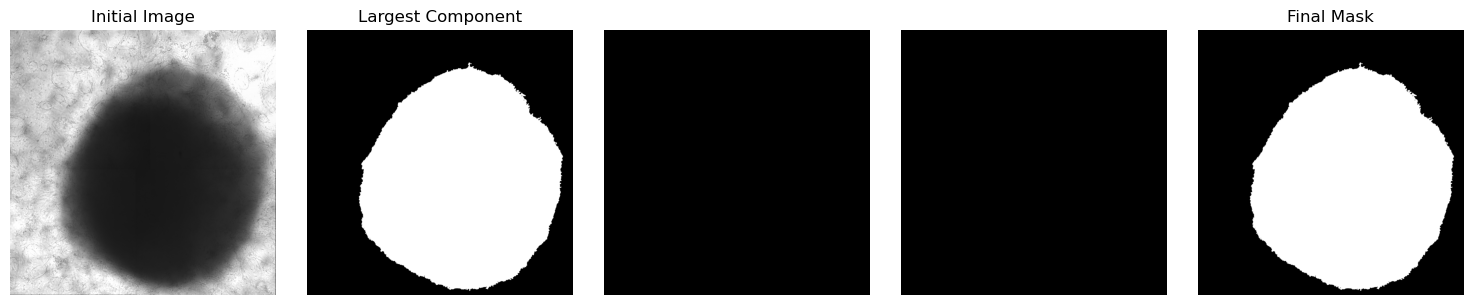

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device1  area=1800379 px²  (3042641 µm²)
  eccentricity=0.625  solidity=0.949
  High eccentricity (0.63) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 187.1)


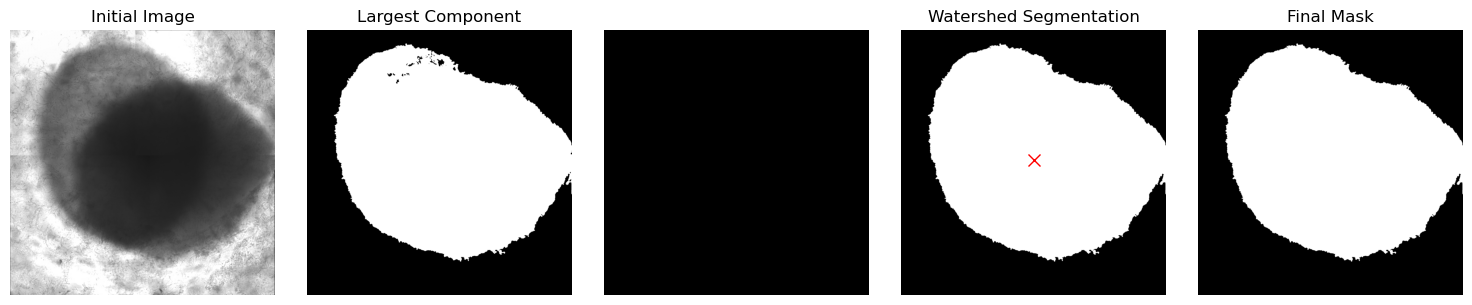

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device2  area=1963963 px²  (3319097 µm²)
  eccentricity=0.585  solidity=0.934


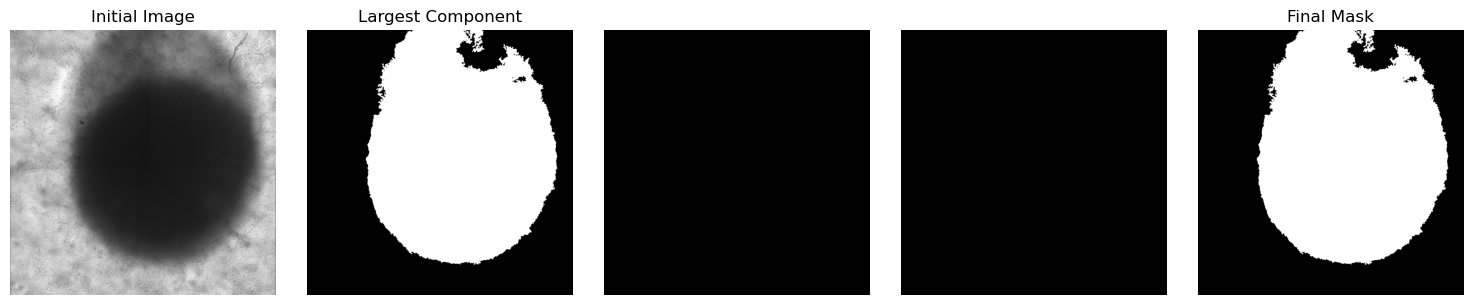

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device3  area=1838425 px²  (3106938 µm²)
  eccentricity=0.476  solidity=0.978


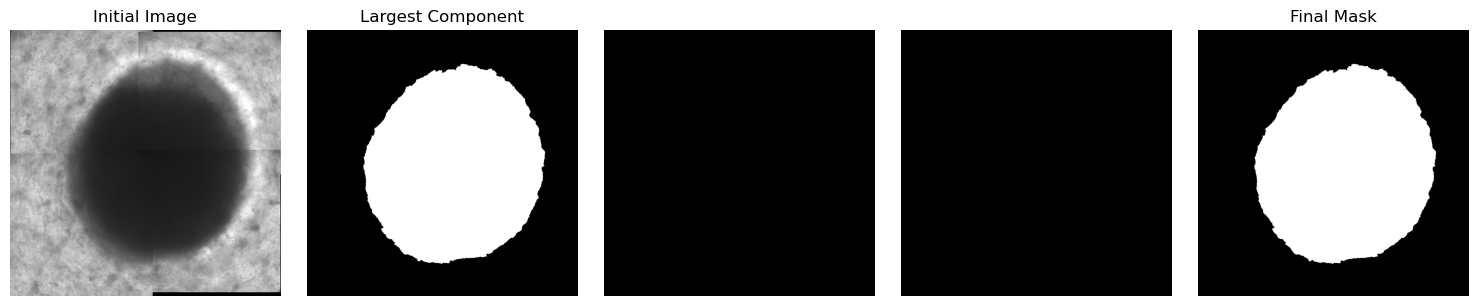

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL12_device4  area=1413615 px²  (2389009 µm²)
  eccentricity=0.612  solidity=0.754
  Low solidity (0.75) — attempting erosion
  7 component(s) after erosion
  Erosion split → kept largest component, eccentricity now 0.778
  High eccentricity (0.78) — attempting watershed
  peak_local_max found 3 peak(s)
  Watershed kept brightest region (mean intensity 212.9)


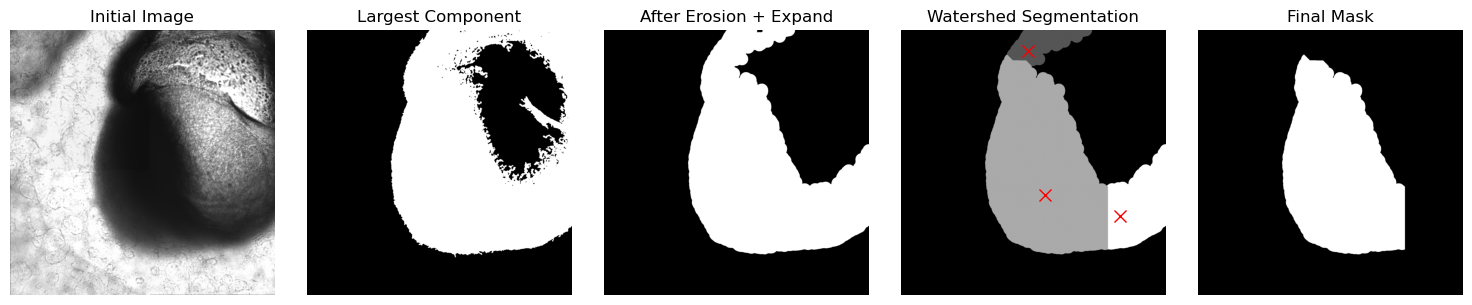

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device1  area=920207 px²  (1555150 µm²)
  eccentricity=0.667  solidity=0.912
  High eccentricity (0.67) — attempting watershed
  peak_local_max found 2 peak(s)
  Watershed kept brightest region (mean intensity 186.2)


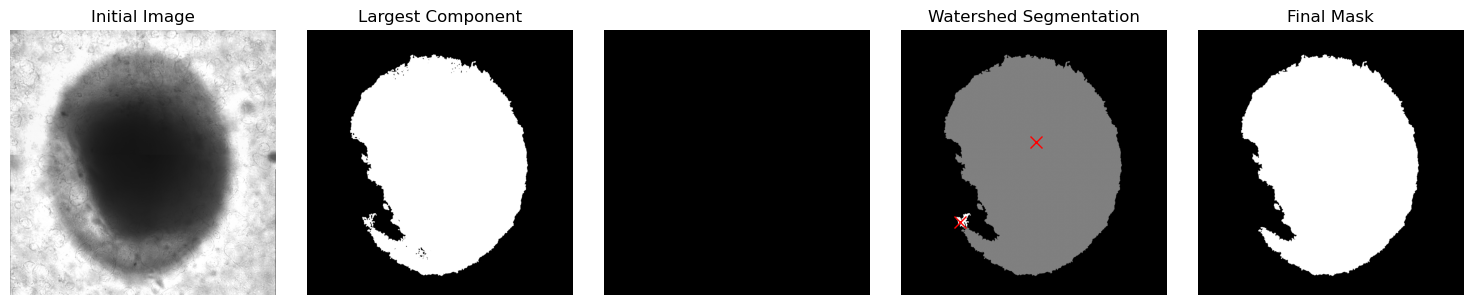

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device2  area=1505369 px²  (2544074 µm²)
  eccentricity=0.463  solidity=0.741
  Low solidity (0.74) — attempting erosion
  11 component(s) after erosion
  Erosion split → kept largest component, eccentricity now 0.836
  High eccentricity (0.84) — attempting watershed
  peak_local_max found 4 peak(s)
  Watershed kept brightest region (mean intensity 208.0)


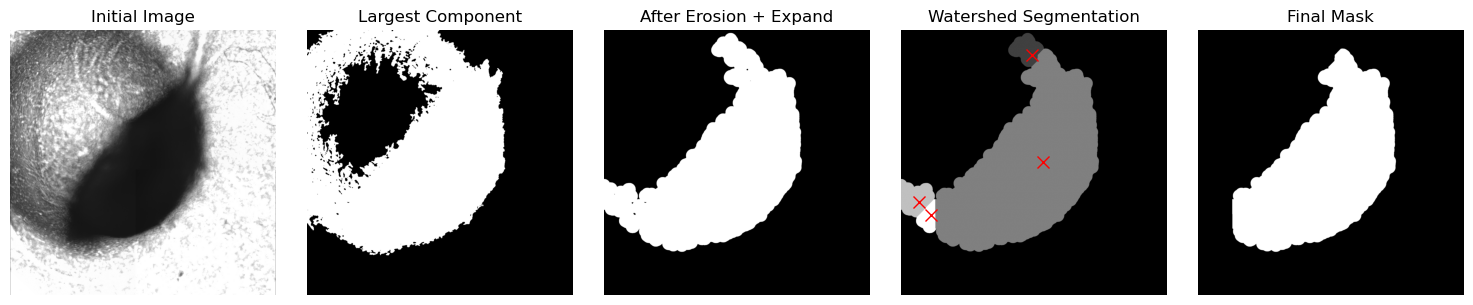

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device3  area=989914 px²  (1672955 µm²)
  eccentricity=0.476  solidity=0.975


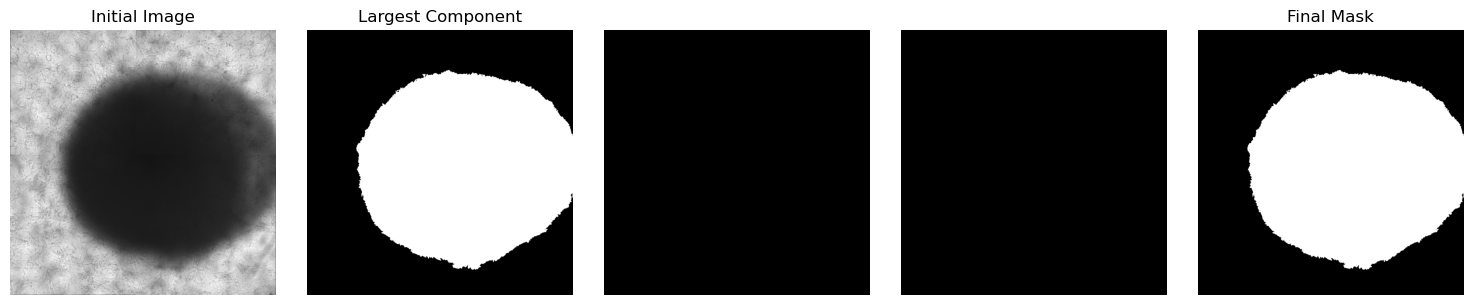

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL12_device4  area=1762706 px²  (2978973 µm²)
  eccentricity=0.695  solidity=0.957
  High eccentricity (0.70) — attempting watershed
  peak_local_max found 2 peak(s)
  Watershed kept brightest region (mean intensity 212.3)


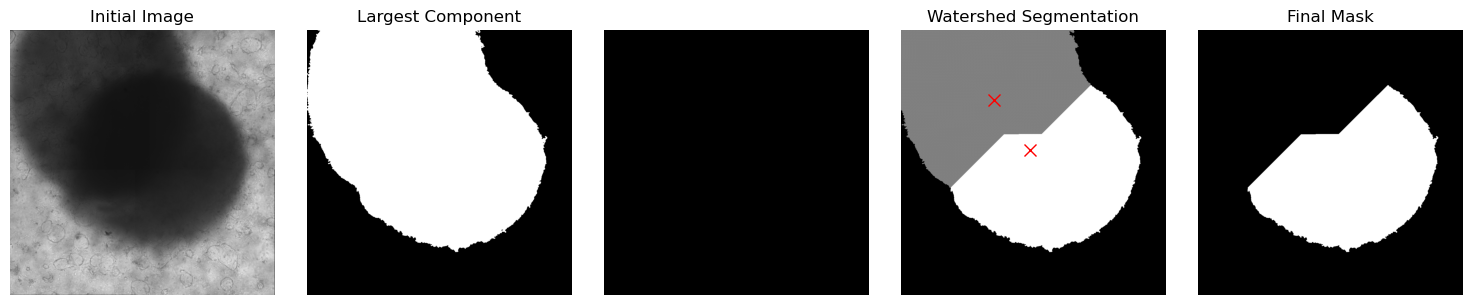

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device1  area=1020909 px²  (1725336 µm²)
  eccentricity=0.706  solidity=0.916
  High eccentricity (0.71) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 194.2)


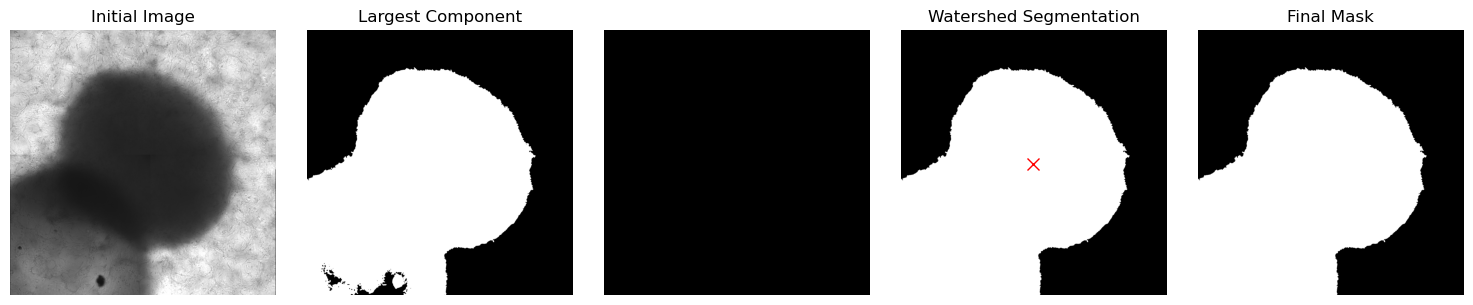

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device2  area=1992610 px²  (3367511 µm²)
  eccentricity=0.717  solidity=0.930
  High eccentricity (0.72) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 196.9)


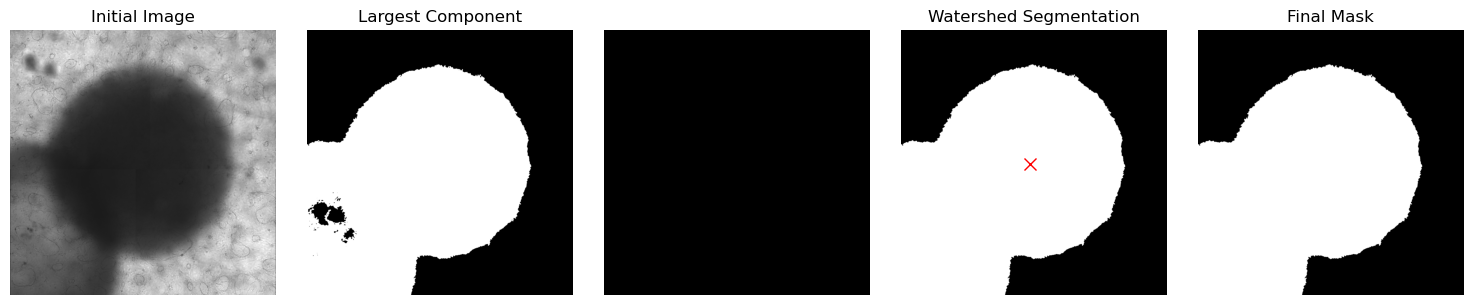

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device3  area=2028632 px²  (3428388 µm²)
  eccentricity=0.730  solidity=0.925
  High eccentricity (0.73) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 206.5)


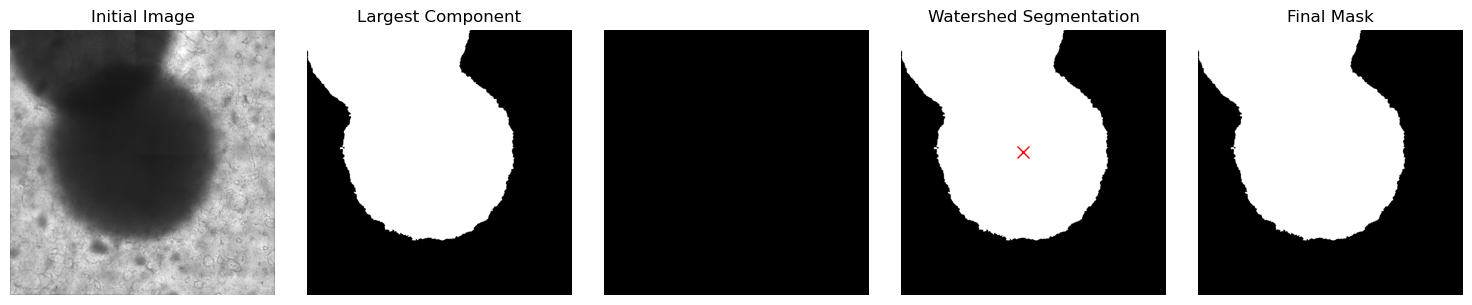

  BF OK  2026.05.14_Size_CART_batchPerm__UTD_FL32_device4  area=1667535 px²  (2818134 µm²)
  eccentricity=0.567  solidity=0.893
  Low solidity (0.89) — attempting erosion
  3 component(s) after erosion
  Erosion split → kept largest component, eccentricity now 0.577


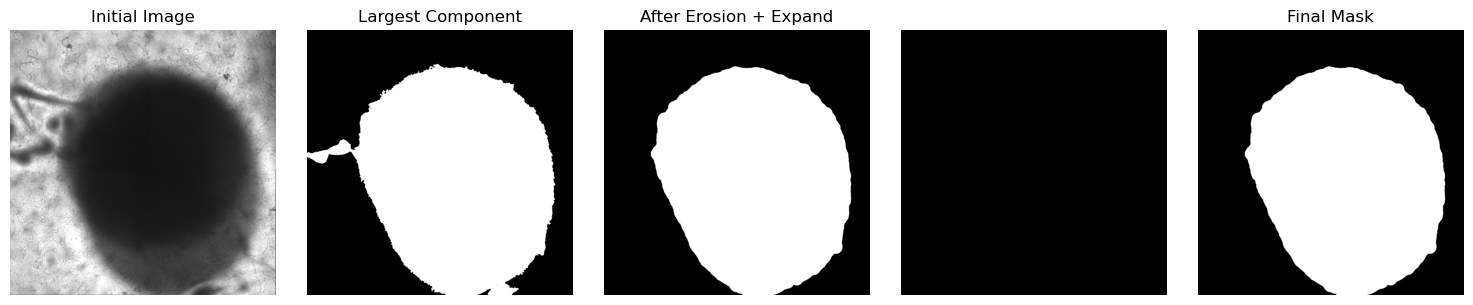

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL32_device1  area=1845640 px²  (3119132 µm²)
  eccentricity=0.696  solidity=0.963
  High eccentricity (0.70) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 209.3)


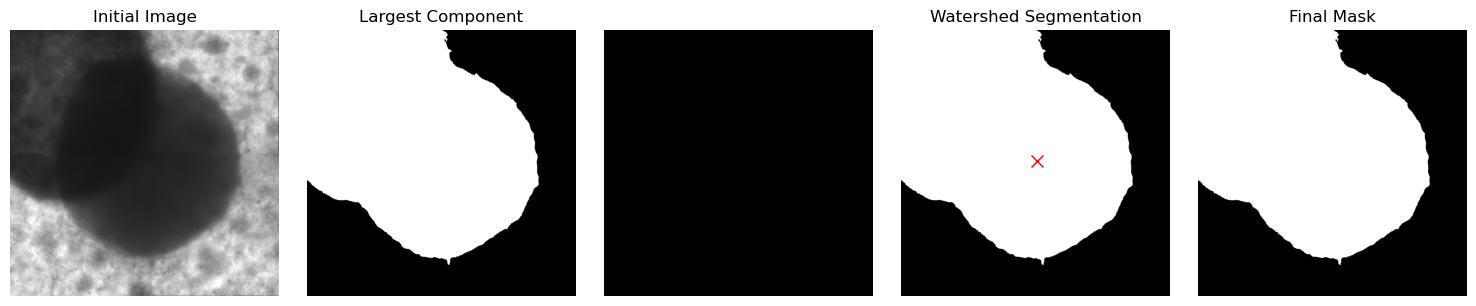

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL32_device2  area=2096528 px²  (3543132 µm²)
  eccentricity=0.641  solidity=0.903
  High eccentricity (0.64) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 202.0)


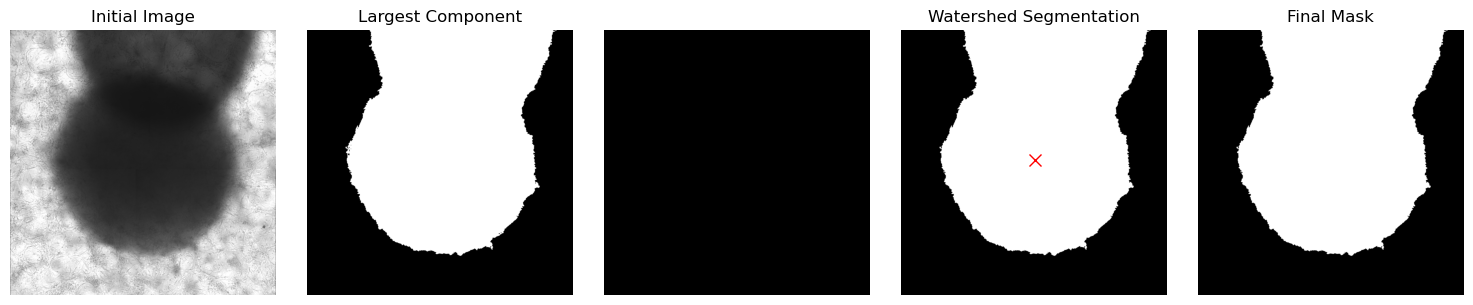

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL32_device3  area=1915868 px²  (3237817 µm²)
  eccentricity=0.338  solidity=0.943


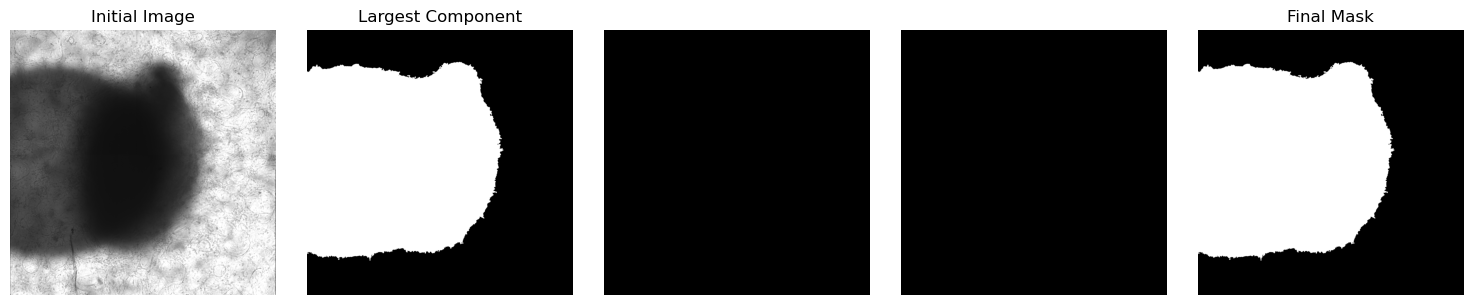

  BF OK  2026.05.14_Size_CART_batchPerm__ARi_FL32_device4  area=1763829 px²  (2980871 µm²)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\2026.05.14_Size_CART_batchPerm\2026.05.14_Size_CART_batchPerm_results.csv  (16 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d1_0062_TRANS.tiff ---
  eccentricity=0.350  solidity=0.960


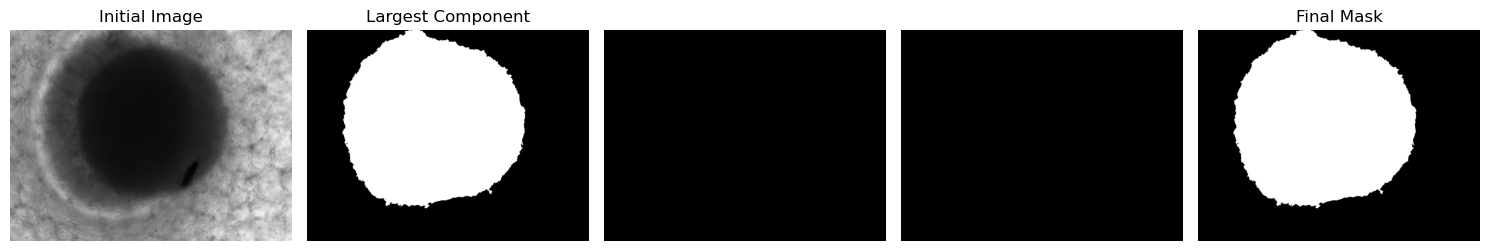

  BF OK  260311_FL12_ARI_dy7_d1_0062_TRANS  area=1301038 px²  (no pixel size)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d1_0062_TRANS\260311_FL12_ARI_dy7_d1_0062_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d2_0061_TRANS.tiff ---
  eccentricity=0.419  solidity=0.977


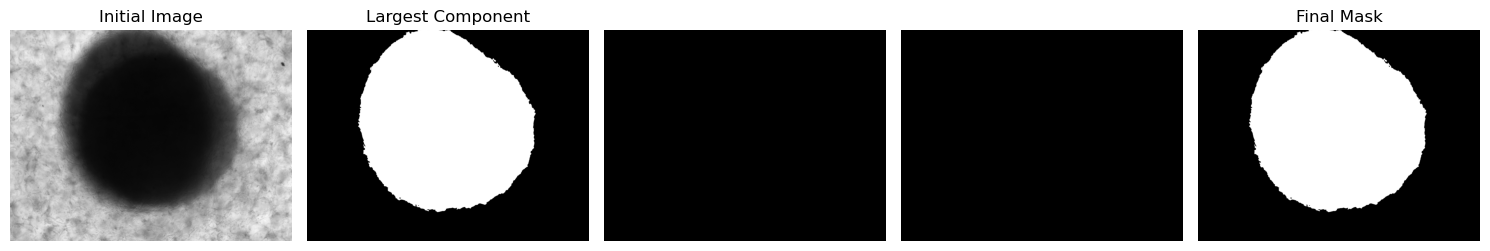

  BF OK  260311_FL12_ARI_dy7_d2_0061_TRANS  area=1285184 px²  (no pixel size)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d2_0061_TRANS\260311_FL12_ARI_dy7_d2_0061_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d3_0060_TRANS.tiff ---
  eccentricity=0.626  solidity=0.883
  Low solidity (0.88) — attempting erosion
  BF ERR 260311_FL12_ARI_dy7_d3_0060_TRANS: cannot convert float NaN to integer
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d3_0060_TRANS\260311_FL12_ARI_dy7_d3_0060_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d4_0059_TRANS.tiff ---
  eccentricity=0.535  solidity=0.971


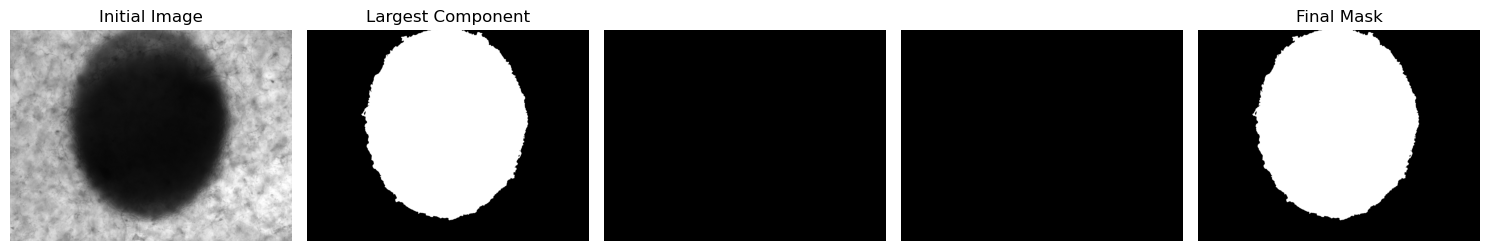

  BF OK  260311_FL12_ARI_dy7_d4_0059_TRANS  area=1261125 px²  (no pixel size)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d4_0059_TRANS\260311_FL12_ARI_dy7_d4_0059_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d5_0058_TRANS.tiff ---
  eccentricity=0.733  solidity=0.917
  High eccentricity (0.73) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 211.5)


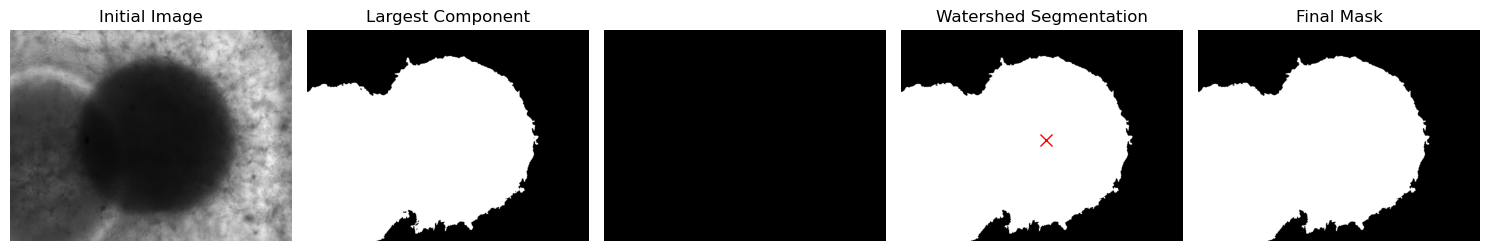

  BF OK  260311_FL12_ARI_dy7_d5_0058_TRANS  area=1741502 px²  (no pixel size)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d5_0058_TRANS\260311_FL12_ARI_dy7_d5_0058_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d6_0057_TRANS.tiff ---
  eccentricity=0.735  solidity=0.478
  Low solidity (0.48) — attempting erosion
  BF ERR 260311_FL12_ARI_dy7_d6_0057_TRANS: cannot convert float NaN to integer
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d6_0057_TRANS\260311_FL12_ARI_dy7_d6_0057_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d7_0056_TRANS.tiff ---
  eccentricity=0.601  solidity=0.974
  High eccentricity (0.60) — attempting watershed
  peak_local_max found 1 peak(s)
  Watershed kept brightest region (mean intensity 229.5)


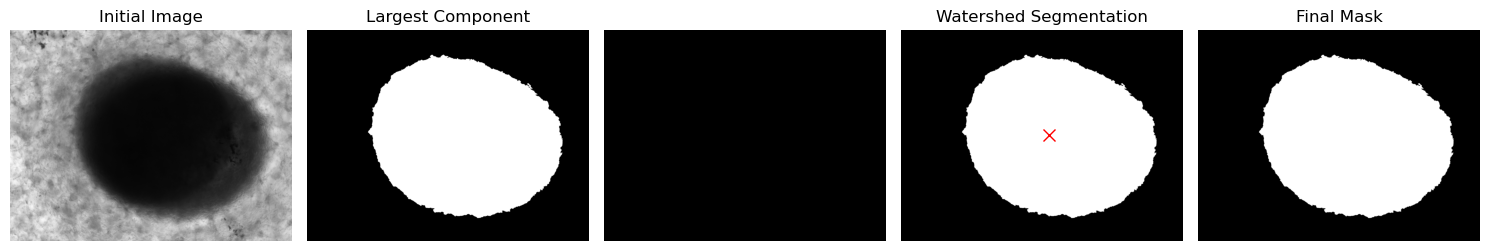

  BF OK  260311_FL12_ARI_dy7_d7_0056_TRANS  area=1245139 px²  (no pixel size)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_ARI_dy7_d7_0056_TRANS\260311_FL12_ARI_dy7_d7_0056_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_UTD_dy7_d1_0050_TRANS.tiff ---
  eccentricity=0.663  solidity=0.971
  High eccentricity (0.66) — attempting watershed
  peak_local_max found 2 peak(s)
  Watershed kept brightest region (mean intensity 222.4)


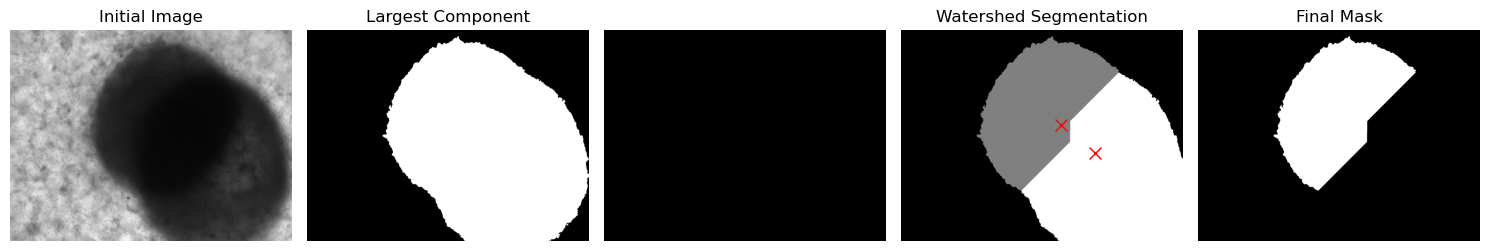

  BF OK  260311_FL12_UTD_dy7_d1_0050_TRANS  area=628428 px²  (no pixel size)
  CSV saved: Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs\Seeding 1 2026.03.16\260311_FL12_UTD_dy7_d1_0050_TRANS\260311_FL12_UTD_dy7_d1_0050_TRANS_results.csv  (1 row(s))

--- Seeding 1 2026.03.16\260311_FL12_UTD_dy7_d2_0049_TRANS.tiff ---


In [ ]:
INPUT_DIR  = Path(r"Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Inputs")
OUTPUT_DIR = Path(r"Z:\Bel\Marina_Side_Projects\Area_PDO\For_Analysis\Outputs")

# ── Pipeline parameters (edit as needed) ──────────────────────────────────────
BF_CHANNEL          = 0     # brightfield channel index
FLUORESCENT_CHANNEL = None  # set to an int (e.g. 1) to also segment a fluorescence channel
# ──────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def safe_filename(name: str) -> str:
    """Strip characters that are illegal in Windows file names."""
    return "".join("_" if c in '<>:"/\\|?*' else c for c in name).strip().strip(".")


def save_segmentation_png(name: str, bf_res: Optional[dict], fl_res: Optional[dict], out_path: Path) -> None:
    """Save a combined segmentation overlay PNG (BF + optional FL)."""
    num_panels = 4 if fl_res is not None else 2
    fig, axes = plt.subplots(1, num_panels, figsize=(4.5 * num_panels, 4.5))
    if bf_res is not None:
        axes[0].imshow(bf_res["rescaled"], cmap="gray")
        axes[0].set_title(f"{name}\nBF rescaled")
        axes[0].axis("off")
        axes[1].imshow(bf_res["rescaled"], cmap="gray")
        if bf_res["mask"].any():
            axes[1].contour(bf_res["mask"], colors="red", linewidths=1.0)
        axes[1].set_title(f"BF  area={bf_res['area_um2']:.0f} um²  ecc={bf_res['eccentricity']:.2f}  split={bf_res['split']}")
        axes[1].axis("off")
    if fl_res is not None:
        axes[2].imshow(fl_res["rescaled"], cmap="gray")
        axes[2].set_title("FL rescaled")
        axes[2].axis("off")
        axes[3].imshow(fl_res["rescaled"], cmap="gray")
        if fl_res["mask"].any():
            axes[3].contour(fl_res["mask"], colors="cyan", linewidths=1.0)
        axes[3].set_title(f"FL  area={fl_res['area_um2']:.0f} um²  ecc={fl_res['eccentricity']:.2f}  split={fl_res['split']}")
        axes[3].axis("off")
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


# ── Main batch loop ────────────────────────────────────────────────────────────
input_files = sorted(p for p in INPUT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in (".tif", ".tiff", ".lif"))
print(f"Found {len(input_files)} input file(s) under {INPUT_DIR}")

for file_path in input_files:
    rel_parent = file_path.relative_to(INPUT_DIR).parent
    out_subdir = OUTPUT_DIR / rel_parent / file_path.stem
    out_subdir.mkdir(parents=True, exist_ok=True)
    csv_path = out_subdir / f"{file_path.stem}_results.csv"

    print(f"\n--- {file_path.relative_to(INPUT_DIR)} ---")
    file_rows: list[dict] = []

    try:
        for name, bf_img2d, fl_img2d, pixel_size_um, skip_reason in iter_images(file_path, bf_channel=BF_CHANNEL, fluorescent_channel=FLUORESCENT_CHANNEL):
            pixel_size_y, pixel_size_x = pixel_size_um
            pixel_size_known = not (np.isnan(pixel_size_y) or np.isnan(pixel_size_x))

            row = {
                "image_name":       name,
                "x_um_per_px":      pixel_size_x,
                "y_um_per_px":      pixel_size_y,
                "skipped":          skip_reason is not None,
                "skip_reason":      skip_reason or "",
                "bf_area_px2":      None,
                "bf_area_um2":      None,
                "fl_area_px2":      None,
                "fl_area_um2":      None,
                "bf_eccentricity":  None,
                "fl_eccentricity":  None,
                "bf_split":         None,
                "fl_split":         None,
                "bf_error":         "",
                "fl_error":         "",
            }

            if skip_reason is not None:
                print(f"  SKIPPED {name}: {skip_reason}")
                file_rows.append(row)
                continue

            bf_res, fl_res = None, None

            # ── Brightfield segmentation ──
            try:
                bf_res = identify_tumour(bf_img2d, pixel_size_um=pixel_size_um, image_type="bf")
                row["bf_area_px2"]     = round(bf_res["area_px2"])
                row["bf_area_um2"]     = round(bf_res["area_um2"], 2) if pixel_size_known else float("nan")
                row["bf_eccentricity"] = round(bf_res["eccentricity"], 4)
                # row["bf_split"]        = bf_res["split"]
                print(f"  BF OK  {name}  area={bf_res['area_px2']:.0f} px²" + (f"  ({bf_res['area_um2']:.0f} µm²)" if pixel_size_known else "  (no pixel size)"))
            except Exception as e:
                row["bf_error"] = f"{type(e).__name__}: {e}"
                print(f"  BF ERR {name}: {e}")

            # ── Fluorescence segmentation (optional) ──
            if fl_img2d is not None:
                try:
                    fl_res = identify_tumour(fl_img2d, pixel_size_um=pixel_size_um, image_type="fluorescent")
                    row["fl_area_px2"]     = round(fl_res["area_px2"])
                    row["fl_area_um2"]     = round(fl_res["area_um2"], 2) if pixel_size_known else float("nan")
                    row["fl_eccentricity"] = round(fl_res["eccentricity"], 4)
                    # row["fl_split"]        = fl_res["split"]
                    print(f"  FL OK  {name}  area={fl_res['area_px2']:.0f} px²" + (f"  ({fl_res['area_um2']:.0f} µm²)" if pixel_size_known else "  (no pixel size)"))
                except Exception as e:
                    row["fl_error"] = f"{type(e).__name__}: {e}"
                    print(f"  FL ERR {name}: {e}")

            # ── Save PNG ──
            # if bf_res is not None or fl_res is not None:
            #     png_path = out_subdir / f"{safe_filename(name)}_segmentation.png"
            #     try:
            #         save_segmentation_png(name, bf_res, fl_res, png_path)
            #     except Exception as e:
            #         print(f"  PNG ERR {name}: {e}")

            file_rows.append(row)

    except Exception as e:
        print(f"  FAILED to open {file_path.name}: {e}")
        traceback.print_exc()
        file_rows.append({
            "image_name": "", "x_um_per_px": None, "y_um_per_px": None,
            "skipped": False, "skip_reason": "",
            "bf_area_px2": None, "bf_area_um2": None,
            "fl_area_px2": None, "fl_area_um2": None,
            "bf_eccentricity": None, "fl_eccentricity": None,
            "bf_split": None, "fl_split": None,
            "bf_error": f"{type(e).__name__}: {e}", "fl_error": "",
        })

    # ── Write per-file CSV ──
    if file_rows:
        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(file_rows[0].keys()))
            writer.writeheader()
            writer.writerows(file_rows)
        print(f"  CSV saved: {csv_path}  ({len(file_rows)} row(s))")
